[*********************100%***********************]  1 of 1 completed

=== CURRENT VOLATILITY REGIME FOR AAPL ===
Current Annualized Volatility: 26.75%
Volatility Percentile Rank: 58.0%
App Recommendation Layer: NORMAL RISK: Standard environment for geometric/technical swing trading setups.

--- 5-Day Swing Horizon Volatility Forecast ---
Day 1 Forward Estimate: 26.60%
Day 2 Forward Estimate: 27.03%
Day 3 Forward Estimate: 27.41%
Day 4 Forward Estimate: 27.73%
Day 5 Forward Estimate: 28.00%


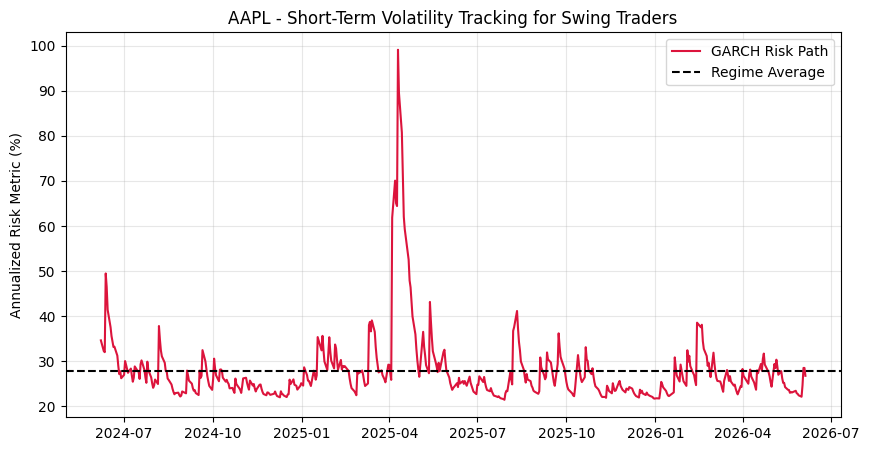

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model


ticker = "AAPL"
# Use 'period="2y"' to capture the current volatility regime instead of old 2020 data
# 'multi_level_index=False' prevents columns from returning as an un-extractable MultiIndex
data = yf.download(ticker, period="2y", multi_level_index=False, auto_adjust=True)

# 2. Calculate daily log returns
data["Log_Return"] = 100 * np.log(data["Close"] / data["Close"].shift(1))
data.dropna(inplace=True)

# 3. Fit GARCH(1,1) using Student's t-distribution for fat-tail asset shocks
# Changing dist to 'StudentsT' is standard quant practice for realistic risk assessment
model = arch_model(data["Log_Return"], vol="Garch", p=1, q=1, dist="StudentsT")
results = model.fit(disp="off")

# 4. Extract annualized conditional volatility
data["Conditional_Volatility"] = results.conditional_volatility * np.sqrt(252)

# 5. CALCULATE VOLATILITY REGIME (Essential for App Context)
current_vol = data["Conditional_Volatility"].iloc[-1]
vol_percentile = (data["Conditional_Volatility"] < current_vol).mean() * 100

print(f"=== CURRENT VOLATILITY REGIME FOR {ticker} ===")
print(f"Current Annualized Volatility: {current_vol:.2f}%")
print(f"Volatility Percentile Rank: {vol_percentile:.1f}%")

# Generate actionable app warnings based on math thresholds
if vol_percentile > 80:
    regime_status = "CRITICAL RISK: Volatility is extremely high. Recommend cutting position sizing by half and widening stop losses."
elif vol_percentile < 20:
    regime_status = "LOW RISK / COMPRESSED: Volatility is coiled tight. Expect a massive breakout swing soon."
else:
    regime_status = "NORMAL RISK: Standard environment for geometric/technical swing trading setups."
print(f"App Recommendation Layer: {regime_status}\n")

# 6. Forecast future volatility for a standard 5-day swing window
forecast_horizon = 5
forecasts = results.forecast(horizon=forecast_horizon)

last_date = data.index[-1]
forecasted_variance = forecasts.variance.iloc[-1]
forecasted_vol = np.sqrt(forecasted_variance) * np.sqrt(252)

print(f"--- 5-Day Swing Horizon Volatility Forecast ---")
for i, vol in enumerate(forecasted_vol, 1):
    print(f"Day {i} Forward Estimate: {vol:.2f}%")

# 7. Plotting the localized chart
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Conditional_Volatility"], color="crimson", label="GARCH Risk Path")
plt.axhline(data["Conditional_Volatility"].mean(), color="black", linestyle="--", label="Regime Average")
plt.title(f"{ticker} - Short-Term Volatility Tracking for Swing Traders")
plt.ylabel("Annualized Risk Metric (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()